In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Pandas Version: {pd.__version__}")

Pandas Version: 3.0.1


In [6]:
np.random.seed(42)
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'age': np.random.randint(22, 35, 5),
    'score': np.random.randint(60, 100, 5),
    'hours_studied': np.random.randint(1, 10, 5)
}
df = pd.DataFrame(data)
df


,name,age,score,hours_studied
0,Alice,28,80,8
1,Bob,25,98,5
2,Charlie,34,78,4
3,Diana,32,82,8
4,Eve,29,70,8


In [9]:
print("Data Summary: ")
print(df.describe())
print("\nData Info:")
print(df.info())


Data Summary: 
             age      score  hours_studied
count   5.000000   5.000000       5.000000
mean   29.600000  81.600000       6.600000
std     3.507136  10.237187       1.949359
min    25.000000  70.000000       4.000000
25%    28.000000  78.000000       5.000000
50%    29.000000  80.000000       8.000000
75%    32.000000  82.000000       8.000000
max    34.000000  98.000000       8.000000

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           5 non-null      str  
 1   age            5 non-null      int32
 2   score          5 non-null      int32
 3   hours_studied  5 non-null      int32
dtypes: int32(3), str(1)
memory usage: 232.0 bytes
None


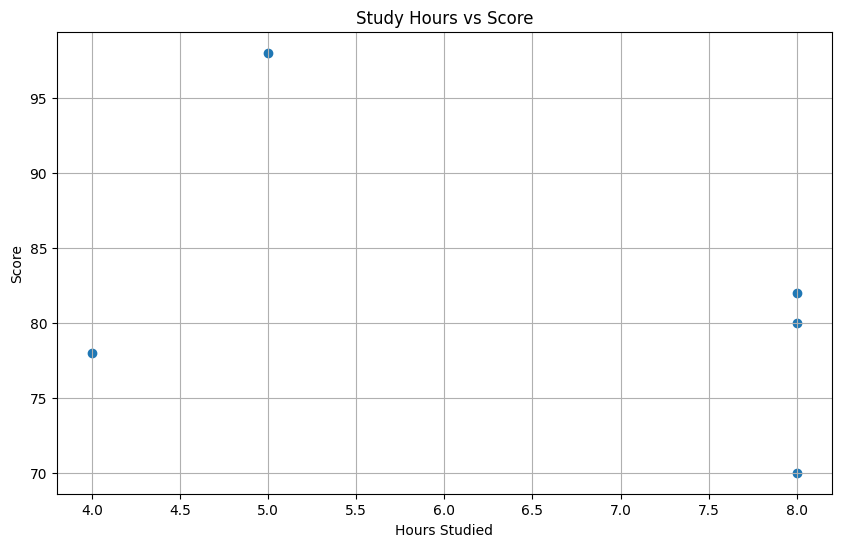

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['hours_studied'], df['score'])
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Study Hours vs Score')
plt.grid(True)
plt.show()

In [8]:
correlation = df['hours_studied'].corr(df['score'])
print(f"Correlation between study hours and score: {correlation:.2f}")

Correlation between study hours and score: -0.44


### Cell 6: Advanced Statistics

In [9]:
from scipy import stats

# Calculate additional statistics
print("=" * 50)
print("ADVANCED STATISTICAL ANALYSIS")
print("=" * 50)

# Normality test
shapiro_stat, shapiro_p = stats.shapiro(df['score'])
print(f"\n1. Normality Test (Shapiro-Wilk):")
print(f"   Statistic: {shapiro_stat:.4f}")
print(f"   P-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("   ✓ Data appears normally distributed")
else:
    print("   ✗ Data may not be normally distributed")

# Confidence intervals
confidence_level = 0.95
degrees_freedom = len(df['score']) - 1
sample_mean = np.mean(df['score'])
sample_standard_error = stats.sem(df['score'])
confidence_interval = stats.t.interval(confidence_level, 
                                        degrees_freedom, 
                                        sample_mean, 
                                        sample_standard_error)

print(f"\n2. 95% Confidence Interval for Scores:")
print(f"   Mean: {sample_mean:.2f}")
print(f"   Interval: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")

ADVANCED STATISTICAL ANALYSIS

1. Normality Test (Shapiro-Wilk):
   Statistic: 0.9141
   P-value: 0.4927
   ✓ Data appears normally distributed

2. 95% Confidence Interval for Scores:
   Mean: 81.60
   Interval: (68.89, 94.31)


### Corelation matrix and Heatmap

CORRELATION MATRIX

Correlation Matrix:
                    age     score  hours_studied
age            1.000000 -0.562624      -0.138957
score         -0.562624  1.000000      -0.435960
hours_studied -0.138957 -0.435960       1.000000


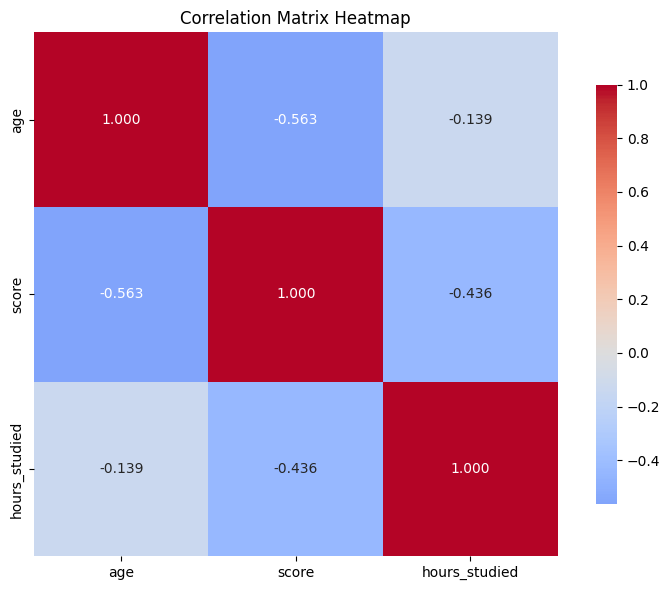

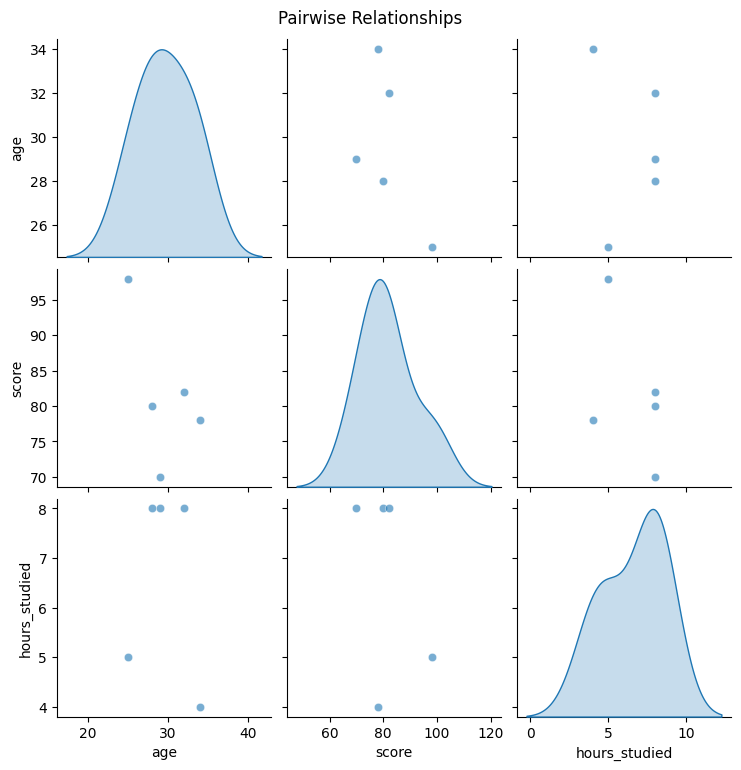

In [11]:
# Advanced Correlation Analysis
print("=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)

# Calculate correlation matrix
correlation_matrix = df[['age', 'score', 'hours_studied']].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Heatmap visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Pairplot for relationships
sns.pairplot(df[['age', 'score', 'hours_studied']], 
             diag_kind='kde',
             plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()